In [13]:
import pandas as pd
import numpy as np
import plotly.express as px
import shap

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, r2_score

from xgboost import XGBRegressor

ROOT = Path.cwd().parents[1]
print(ROOT)

DATA_RAW = ROOT/"data/raw"
DATA_PROCESSED = ROOT/"data/processed"

c:\Users\sebas\PycharmProjects\Git\BoxOffice_Oracle


In [14]:
model_df = pd.read_csv(
    DATA_RAW/"fe_groups/g2.csv"
)

print(model_df.shape)
model_df.head()

(2255, 118)


,Unnamed: 0,tconst,primaryTitle,startYear,opening_weekend_gross,opening_theaters,domestic_release_date,release_type,all_domestic_release_types,distributor,...,g2b_top3_actor_pct_change_last_min,g2b_top3_actor_pct_acceleration_last_mean,g2b_top3_actor_pct_acceleration_last_max,g2b_top3_actor_pct_acceleration_last_min,g2b_top3_actor_velocity_per_day_last_mean,g2b_top3_actor_velocity_per_day_last_max,g2b_top3_actor_velocity_per_day_last_min,g2b_top3_actor_acceleration_per_day_last_mean,g2b_top3_actor_acceleration_per_day_last_max,g2b_top3_actor_acceleration_per_day_last_min
0,0,tt1311067,Halloween II,2009.0,7676836.0,1217.0,1981-10-30,Wide,Wide,Universal,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,tt0816462,Conan the Barbarian,2011.0,9479373.0,1358.0,1982-05-14,Wide,Wide,Universal,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,tt4731008,The Wild Life,2016.0,4001400.0,1140.0,1984-09-28,Wide,Wide,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,tt1160419,Dune: Part One,2021.0,6025091.0,915.0,1984-12-14,Wide,Wide,Universal,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,tt1540128,Playing for Keeps,2012.0,1406300.0,1148.0,1986-10-03,Wide,Wide,Universal,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [98]:
corr_to_target_abs = (
    model_df.drop(columns=["opening_theaters","opening_weekend_gross"]).corr(numeric_only=True)["log_opening_weekend_gross"]
    .drop("log_opening_weekend_gross")
    .abs()
    .sort_values(ascending=False)
)

corr_to_target_abs.head(20)

legs                                            0.432508
production_budget                               0.387897
release_day_of_year                             0.287108
release_month                                   0.285844
g2b_acceleration_per_day_last_actor_3           0.211379
g2b_pct_change_last_director                    0.144047
g2b_raw_acceleration_last_actor_2               0.113698
g2b_is_heating_up_distributor                   0.095048
g2b_velocity_per_day_last_actor_3               0.094997
g2b_raw_change_last_writer                      0.083489
g2b_is_cooling_down_actor_1                     0.076571
g2b_is_heating_up_genre                         0.072626
startYear                                       0.071161
g2b_is_cooling_down_director                    0.065991
g2b_top3_actor_acceleration_per_day_last_max    0.064087
g2b_is_neutral_momentum_director                0.064077
runtime_minutes                                 0.061017
g2b_is_cooling_down_genre      

In [109]:
g2b_features = [    
    "g2b_pct_change_last_director",
    "g2b_pct_acceleration_last_director",
    "g2b_velocity_per_day_last_director",
    "g2b_acceleration_per_day_last_director",

    "g2b_pct_change_last_writer",
    "g2b_pct_acceleration_last_writer",

    "g2b_top3_actor_pct_change_last_mean",
    "g2b_top3_actor_pct_acceleration_last_mean",
    "g2b_top3_actor_velocity_per_day_last_mean",
    "g2b_top3_actor_acceleration_per_day_last_mean",

    "g2b_pct_change_last_distributor",
    "g2b_pct_acceleration_last_distributor",

    "g2b_pct_change_last_genre",
    "g2b_pct_acceleration_last_genre",
]

In [100]:
target = "log_opening_weekend_gross"

numeric_features = [
    # "opening_theaters",
    "production_budget",
    "runtime_minutes",
    "release_month",
    "release_day_of_year",
] + g2b_features

people_features = [
    "director_id",
    "writer_id",
    "actor_1",
    "actor_2",
    "actor_3",
]

categorical_features = [
    # "release_type",
    "distributor",
    "MPA_rating",
    "genre",
    "subgenre",
    "source",
    "production_method",
    "creative_type",
    "production_countries",
    "languages",
    # "franchise"
] + people_features

In [101]:
model_df = model_df[
    model_df["franchise"].isna() |
    (model_df["franchise"].astype(str).str.strip() == "")
].copy()

In [102]:
feature_cols = numeric_features + categorical_features

model_data = model_df[
    feature_cols + [target, "opening_weekend_gross"]
].copy()

X = model_data[feature_cols]
y = model_data[target]

print(X.shape)
print(y.shape)

(1493, 25)
(1493,)


In [103]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [104]:
y_test_dollars = np.expm1(y_test)

In [105]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [106]:
def evaluate_model(name, model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)

    pred_log = model.predict(X_test)

    r2_log = r2_score(y_test, pred_log)
    mae_log = mean_absolute_error(y_test, pred_log)

    pred_dollars = np.expm1(pred_log)

    mae_dollars = mean_absolute_error(y_test_dollars, pred_dollars)

    results = {
        "model": name,
        "r2_log": r2_log,
        "mae_log": mae_log,
        "mae_dollars": mae_dollars
    }

    return results, pred_log, pred_dollars

In [107]:
ridge_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", Ridge(alpha=1.0))
])

ridge_results, ridge_pred_log, ridge_pred_dollars = evaluate_model(
    "Ridge Baseline",
    ridge_model,
    X_train,
    X_test,
    y_train,
    y_test
)

ridge_results

{'model': 'Ridge Baseline',
 'r2_log': 0.5122279935691062,
 'mae_log': 0.9019567454950361,
 'mae_dollars': 7877667.592249583}

In [108]:
xgb_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42
    ))
])

xgb_results, xgb_pred_log, xgb_pred_dollars = evaluate_model(
    "XGBoost Baseline",
    xgb_model,
    X_train,
    X_test,
    y_train,
    y_test
)

xgb_results

{'model': 'XGBoost Baseline',
 'r2_log': 0.5468450237090645,
 'mae_log': 0.8149559118515878,
 'mae_dollars': 6339318.066367057}

In [88]:
results_df = pd.DataFrame([
    ridge_results,
    xgb_results
])

results_df

,model,r2_log,mae_log,mae_dollars
0,Ridge Baseline,0.528193,0.886185,7.707467e+06
1,XGBoost Baseline,0.567482,0.791630,6.354720e+06


In [89]:
plot_df = pd.DataFrame({
    "actual": y_test_dollars,
    "predicted": xgb_pred_dollars
})

fig = px.scatter(
    plot_df,
    x="actual",
    y="predicted",
    title="XGBoost Baseline: Actual vs Predicted",
    opacity=0.6
)

fig.add_shape(
    type="line",
    x0=plot_df["actual"].min(),
    y0=plot_df["actual"].min(),
    x1=plot_df["actual"].max(),
    y1=plot_df["actual"].max(),
)

fig.show()

In [90]:
X_train_transformed = (
    xgb_model.named_steps["preprocessor"]
    .transform(X_train)
)

X_test_transformed = (
    xgb_model.named_steps["preprocessor"]
    .transform(X_test)
)

feature_names = (
    xgb_model.named_steps["preprocessor"]
    .get_feature_names_out()
)

trained_xgb = xgb_model.named_steps["model"]

In [91]:
explainer = shap.TreeExplainer(trained_xgb)

X_shap = X_test_transformed[:500]

shap_values = explainer.shap_values(X_shap)

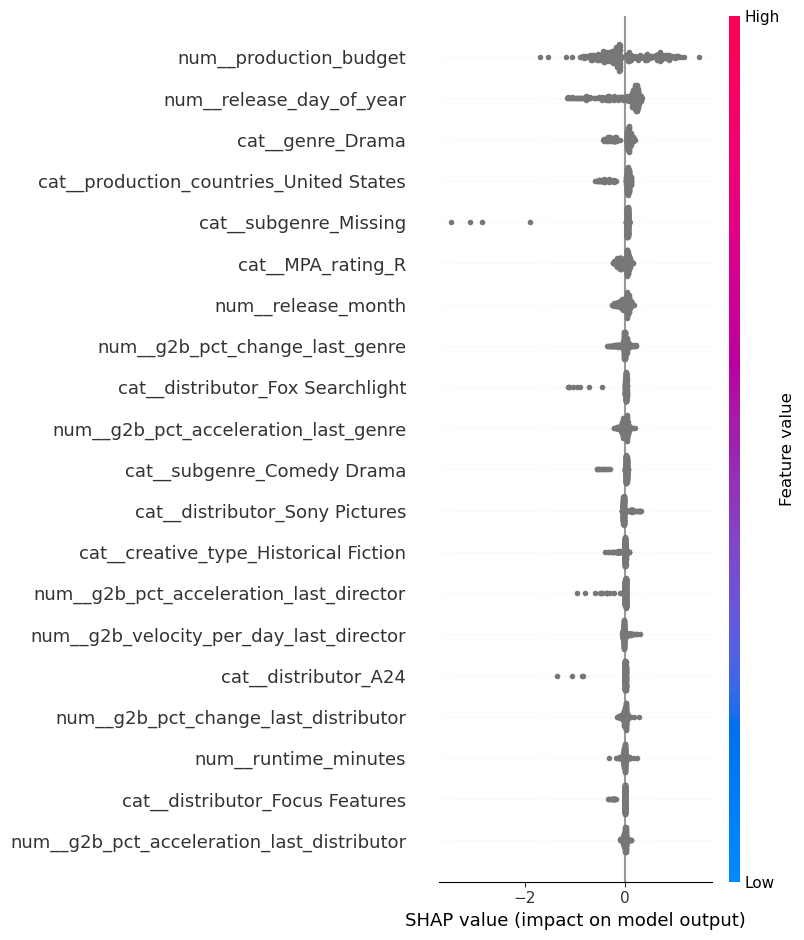

In [92]:
shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=feature_names
)

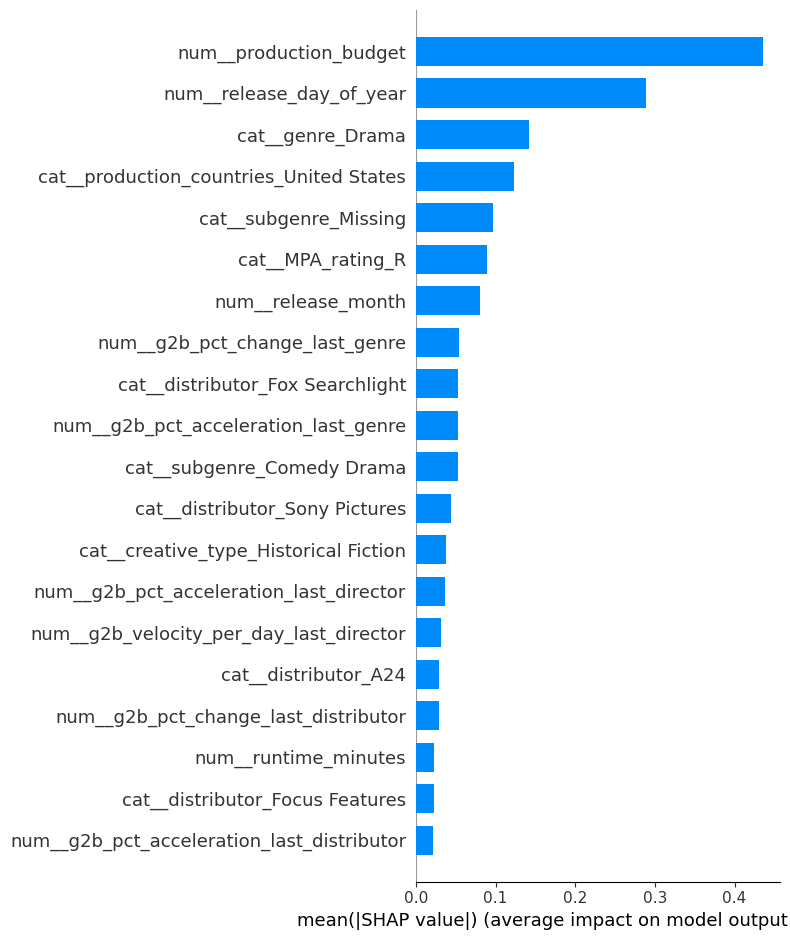

In [93]:
shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=feature_names,
    plot_type="bar"
)

In [94]:
error_df = X_test.copy()

error_df["actual_log"] = y_test
error_df["pred_log"] = xgb_pred_log

error_df["actual_opening_weekend"] = np.expm1(y_test)
error_df["pred_opening_weekend"] = xgb_pred_dollars

error_df["abs_error"] = (
    error_df["actual_opening_weekend"] -
    error_df["pred_opening_weekend"]
).abs()

error_df.sort_values("abs_error", ascending=False).head(20)

,production_budget,runtime_minutes,release_month,release_day_of_year,g2b_pct_change_last_director,g2b_pct_acceleration_last_director,g2b_velocity_per_day_last_director,g2b_acceleration_per_day_last_director,g2b_pct_change_last_writer,g2b_pct_acceleration_last_writer,...,director_id,writer_id,actor_1,actor_2,actor_3,actual_log,pred_log,actual_opening_weekend,pred_opening_weekend,abs_error
39,25000000.0,127.0,2,56,NaN,NaN,NaN,NaN,NaN,NaN,...,nm0000154,nm0280179,nm0001029,nm0000899,nm0411581,18.244517,15.661575,83848082.0,6334840.5,77513241.5
1393,95000000.0,105.0,3,72,NaN,NaN,NaN,NaN,NaN,NaN,...,nm7633075,nm7633074,nm11673205,nm7633076,nm8063245,18.033213,16.742128,67877361.0,18664396.0,49212965.0
77,125000000.0,123.0,5,149,NaN,NaN,NaN,NaN,NaN,NaN,...,nm0000386,nm0000386,nm0000598,nm0350453,nm0002536,18.045894,16.974815,68743584.0,23554216.0,45189368.0
1795,55000000.0,134.0,11,306,-0.275854,-2.614686,-34087.208163,-297.716547,NaN,NaN,...,nm0001741,nm0565026,nm1785339,nm2377903,nm3152605,17.748534,16.262995,51061119.0,11559228.0,39501891.0
742,175000000.0,89.0,5,149,NaN,NaN,NaN,NaN,NaN,NaN,...,nm0230032,nm0677037,nm0000799,nm2973712,nm0001652,18.036617,17.398722,68108790.0,35988920.0,32119870.0
95,105000000.0,115.0,7,198,NaN,NaN,NaN,NaN,NaN,NaN,...,nm0001639,nm0899113,nm0000226,nm0005256,nm0339304,17.770208,17.063498,52179887.0,25738476.0,26441411.0
71,170000000.0,132.0,5,128,NaN,NaN,NaN,NaN,NaN,NaN,...,nm0814085,nm0814085,nm0413168,nm0000295,nm0746896,17.761897,17.055870,51748040.0,25542900.0,26205140.0
833,80000000.0,138.0,2,50,30.336607,NaN,39558.428571,NaN,NaN,NaN,...,nm0000217,nm0436164,nm0000138,nm0607865,nm0749263,17.530604,16.634087,41062440.0,16752977.0,24309463.0
990,200000000.0,113.0,6,168,-0.578421,-2.079150,-20204.253208,-107.918526,NaN,NaN,...,nm0132709,nm0075528,nm0005351,nm0515116,nm0765597,17.789086,17.219677,53174303.0,30089204.0,23085099.0
441,NaN,103.0,2,40,2.346464,NaN,14852.258442,NaN,NaN,NaN,...,nm0005367,nm0000552,nm0000552,nm0628601,nm0187719,17.347603,16.260769,34195434.0,11533528.0,22661906.0


In [95]:
results_df.to_csv(
    DATA_PROCESSED/"feature_testing/results/g2_model_results.csv",
    index=False
)

error_df.to_csv(
    DATA_PROCESSED/"feature_testing/errors/g2_xgb_test_errors.csv",
    index=False
)